# 04 — The box

Two fly brains in bodies, in a MuJoCo room, with a moving hand. Read `docs/04-the-box.md` alongside.
Needs everything notebook 03 needed, plus `mujoco` (installed with the project).

In [1]:
import os, sys; sys.path.insert(0, "..")
os.environ["FLYVIS_ROOT_DIR"] = os.path.abspath("../data/flyvis")
os.environ.setdefault("MUJOCO_GL", "glfw")
import numpy as np, polars as pl, mujoco
from flyhigh.data.connectome import Connectome
from flyhigh.agent import FlyAgent
from flyhigh.motor.readout import ReadoutParams
from flyhigh.sim import Simulation, VideoWriter
import matplotlib as mpl, matplotlib.pyplot as plt
# dataviz conventions: fixed categorical order, single-hue sequential, thin marks, recessive grid
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.6,
                     "axes.prop_cycle": mpl.cycler(color=C), "lines.linewidth": 2, "font.size": 10})
c = Connectome.load("../data/raw")
agent = FlyAgent(c, n_agents=2, params=ReadoutParams(forward_bias=0.0), alignment_path="../data/cache/alignment.parquet")
sim = Simulation(agent, n_agents=2)
print(f"room {sim.room.size} m, {sim.n_agents} flies, {sim.physics_per_tick} physics steps per 10 ms tick")

/home/martin/dev_works/Side_Projects/Flyhigh/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-09-20 16:36:54] network_view:122 Initialized network view at /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000


[2026-09-20 16:36:54] logging_utils:23 epe not in /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.


[2026-09-20 16:37:00] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


[2026-09-20 16:37:00] chkpt_utils:36 Recovered network state.


room (6.0, 6.0, 3.0) m, 2 flies, 5 physics steps per 10 ms tick


## 1. The room, from above and through a fly's eye
An optomotor drum: striped side walls, plain everything else. The only dark things are the hand (right) and the other fly.

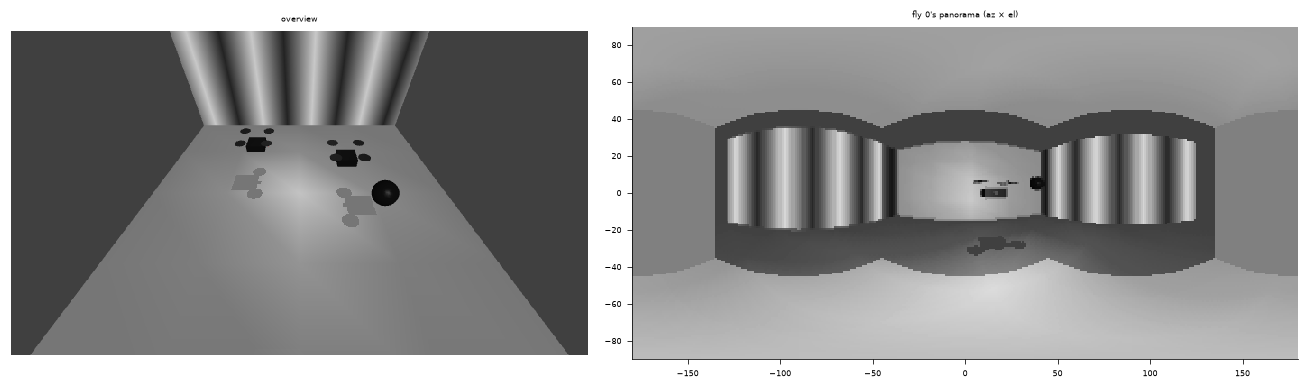

In [2]:
over = mujoco.Renderer(sim.model, 360, 640); over.update_scene(sim.data, camera="overview"); top = over.render(); over.close()
pano = sim.frames()[0].lum
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.3, 1.5]})
axes[0].imshow(top); axes[0].set_title("overview"); axes[0].axis("off")
axes[1].imshow(pano, cmap="gray", vmin=0, vmax=1, extent=[-180, 180, -90, 90]); axes[1].set_title("fly 0's panorama (az × el)"); axes[1].grid(False)
plt.tight_layout()

## 2. The hand
The hand comes at fly 0 from ahead-right at 1 m/s, following it, and stops 20 cm from its surface. Fly 0 escapes; fly 1 watches.
The video (overview + fly 0's eye) is written to `../data/runs/04_hand.mp4`.

[2026-09-20 16:37:05] _io:561 IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 680) to (640, 688) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


fly 0 first escape at hand distance 0.44 m;  fly 1 escapes: 0


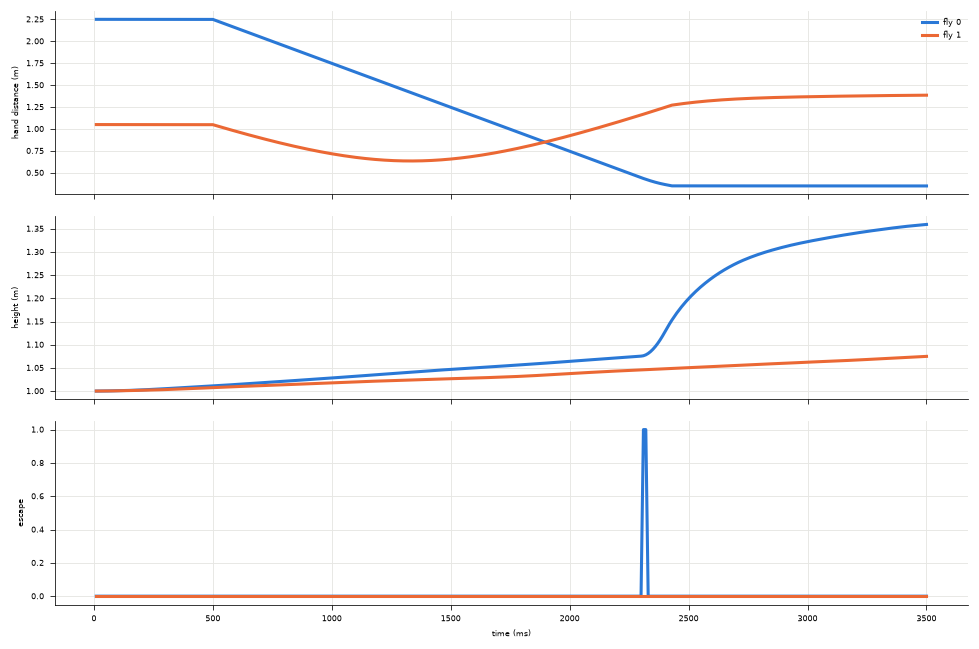

In [3]:
os.makedirs("../data/runs", exist_ok=True)
video = VideoWriter(sim, "../data/runs/04_hand.mp4", every=4)
sim.run(0.5, on_tick=video)
sim.hand.approach(lambda b=sim.bodies[0]: b.pos)
log = sim.run(3.0, on_tick=video)
video.close()
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i in (0, 1):
    a = log.filter(pl.col("agent") == i)
    axes[0].plot(a["t_ms"], a["hand_dist"], color=C[i], label=f"fly {i}")
    axes[1].plot(a["t_ms"], a["z"], color=C[i])
    axes[2].plot(a["t_ms"], a["escape"].cast(pl.Float64), color=C[i])
axes[0].set_ylabel("hand distance (m)"); axes[0].legend(); axes[1].set_ylabel("height (m)"); axes[2].set_ylabel("escape"); axes[2].set_xlabel("time (ms)")
plt.tight_layout()
e = log.filter((pl.col("agent") == 0) & pl.col("escape"))
print("fly 0 first escape at hand distance", None if e.height == 0 else round(e["hand_dist"][0], 2), "m;  fly 1 escapes:", log.filter((pl.col("agent") == 1) & pl.col("escape")).height)

## 3. Self-rotation and the optomotor stabiliser
Impose a 30°/s yaw for 500 ms; the brain commands a turn the other way — the M2 optomotor reflex acting as a heading stabiliser.

[2026-09-20 16:37:43] network_view:122 Initialized network view at /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000


[2026-09-20 16:37:49] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


[2026-09-20 16:37:49] chkpt_utils:36 Recovered network state.


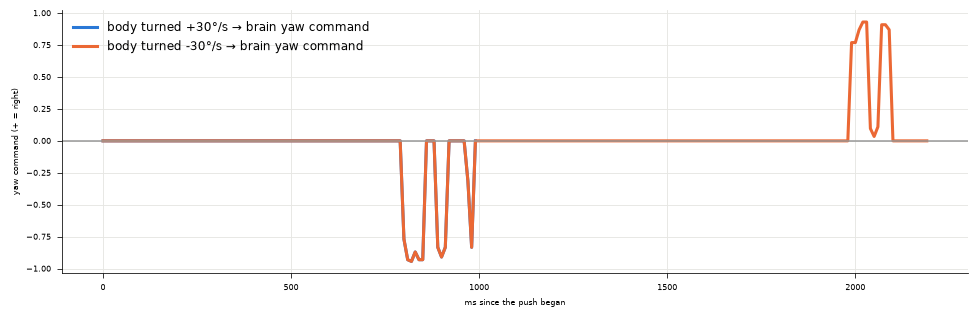

In [4]:
sim.close()
agent1 = FlyAgent(c, n_agents=1, alignment_path="../data/cache/alignment.parquet")
sim1 = Simulation(agent1, n_agents=1)
sim1.run(0.5)
traces = {}
for rate in (+30.0, -30.0):
    sim1.disturb_yaw[0] = rate; log = sim1.run(0.5); sim1.disturb_yaw.clear(); sim1.run(0.7)
    traces[rate] = log.filter(pl.col("agent") == 0)
fig, ax = plt.subplots(figsize=(9, 3))
for k, (rate, a) in enumerate(traces.items()):
    ax.plot(a["t_ms"] - a["t_ms"][0], a["yaw"], color=C[k], label=f"body turned {rate:+.0f}°/s → brain yaw command")
ax.axhline(0, color="#999", lw=1); ax.set_xlabel("ms since the push began"); ax.set_ylabel("yaw command (+ = right)"); ax.legend(fontsize=8)
plt.tight_layout(); sim1.close()

## 4. Two flies
Facing each other, cruising at 0.5 m/s. Top view of the trajectories; escapes marked. Then the same with both flies as ghosts (invisible, no contacts).

[2026-09-20 16:38:17] network_view:122 Initialized network view at /home/martin/dev_works/Side_Projects/Flyhigh/data/flyvis/results/flow/0000/000


[2026-09-20 16:38:24] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.


[2026-09-20 16:38:24] chkpt_utils:36 Recovered network state.


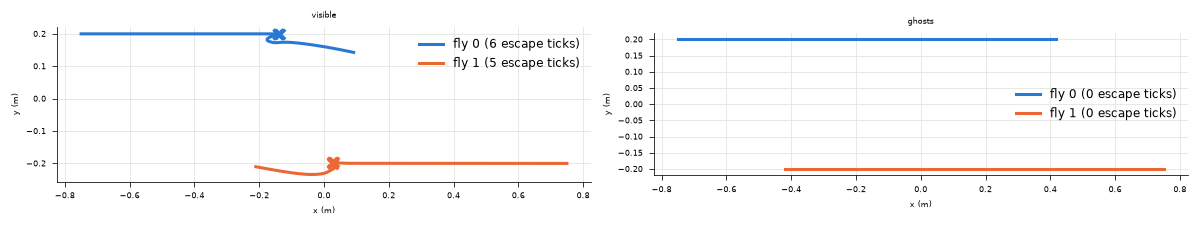

In [5]:
agent2 = FlyAgent(c, n_agents=2, alignment_path="../data/cache/alignment.parquet")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, hidden in zip(axes, (False, True)):
    sim2 = Simulation(agent2, n_agents=2, settle_s=0.0); sim2.hand.park()
    if hidden: sim2.hide_agent(0); sim2.hide_agent(1)
    sim2.settle(0.5); log = sim2.run(2.5); sim2.close()
    for i in (0, 1):
        a = log.filter(pl.col("agent") == i); e = a.filter(pl.col("escape"))
        ax.plot(a["x"], a["y"], color=C[i], label=f"fly {i} ({e.height} escape ticks)")
        ax.scatter(e["x"], e["y"], color=C[i], s=40, marker="x")
    ax.set_title("ghosts" if hidden else "visible"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal"); ax.legend(fontsize=8)
plt.tight_layout()

## Try it
- `sim.hand.speed = 2.5` — a swat; or `RoomParams(hand_radius=0.25)` — a ball.
- `RoomParams(size=(4, 4, 3))` — the smaller room where cruising past the stripes fires the giant fiber.
- Replace `Body.apply` with a rotor model: the interface is one method.